# Import Lib

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_absolute_error

import warnings
warnings.filterwarnings("ignore")

# Load Dataset

In [4]:
file_path = "/content/sample_data/air-temperature-observations.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset loaded successfully!
Shape: (39935, 7)

Columns:
['date_time', 'location_description', 'air_temperature', 'latitude', 'longitude', 'point', 'group']

First 5 rows:


,date_time,location_description,air_temperature,latitude,longitude,point,group
0,2025-04-09T12:18:04+00:00,Rowing Course,13.7,-37.554043,143.824593,"-37.554043, 143.8245927",Lake Wendouree
1,2025-04-10T16:54:23+00:00,Rowing Course,13.2,-37.554043,143.824593,"-37.554043, 143.8245927",Lake Wendouree
2,2025-04-10T23:25:22+00:00,Rowing Course,15.6,-37.554043,143.824593,"-37.554043, 143.8245927",Lake Wendouree
3,2025-04-10T20:39:50+00:00,Rowing Course,13.6,-37.554043,143.824593,"-37.554043, 143.8245927",Lake Wendouree
4,2025-04-11T01:56:05+00:00,Rowing Course,19.0,-37.554043,143.824593,"-37.554043, 143.8245927",Lake Wendouree


In [5]:
print("Dataset Information")
print("=" * 50)

df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39935 entries, 0 to 39934
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   date_time             39935 non-null  object 
 1   location_description  39935 non-null  object 
 2   air_temperature       39935 non-null  float64
 3   latitude              39935 non-null  float64
 4   longitude             39935 non-null  float64
 5   point                 39935 non-null  object 
 6   group                 39935 non-null  object 
dtypes: float64(3), object(4)
memory usage: 2.1+ MB

Missing values:
date_time               0
location_description    0
air_temperature         0
latitude                0
longitude               0
point                   0
group                   0
dtype: int64

Number of duplicate rows:
0


# Data Prepration

In [6]:
# Convert date_time to datetime
df["date_time"] = pd.to_datetime(
    df["date_time"],
    utc=True
)

# Convert temperature to numeric
df["air_temperature"] = pd.to_numeric(
    df["air_temperature"],
    errors="coerce"
)

# Remove missing values
df = df.dropna(
    subset=["date_time", "air_temperature"]
)

# Sort by date/time
df = df.sort_values("date_time")

print("Data prepared successfully.")

print("\nFirst observation:")
print(df[["date_time", "air_temperature"]].head())

print("\nLast observation:")
print(df[["date_time", "air_temperature"]].tail())

Data prepared successfully.

First observation:
                      date_time  air_temperature
34931 2025-04-07 06:44:30+00:00             12.1
1282  2025-04-07 06:59:53+00:00             12.1
13279 2025-04-07 07:14:43+00:00             12.4
2041  2025-04-07 07:30:02+00:00             12.4
80    2025-04-07 07:59:50+00:00             12.1

Last observation:
                      date_time  air_temperature
13238 2026-08-07 07:50:02+00:00             11.3
13239 2026-08-07 08:19:55+00:00             11.1
39933 2026-08-07 08:50:32+00:00             10.9
39931 2026-08-07 09:20:48+00:00             10.6
39934 2026-08-07 09:35:57+00:00             10.3


In [7]:
# Set date_time as index
df = df.set_index("date_time")

# Convert observations into daily mean temperature
daily_temp = df["air_temperature"].resample("D").mean()

# Remove dates without observations
daily_temp = daily_temp.dropna()

print("Daily temperature series created.")

print("\nNumber of daily observations:", len(daily_temp))

print("\nFirst 10 daily observations:")
display(daily_temp.head(10))

print("\nLast 10 daily observations:")
display(daily_temp.tail(10))

Daily temperature series created.

Number of daily observations: 487

First 10 daily observations:


,air_temperature
date_time,
2025-04-07 00:00:00+00:00,9.903175
2025-04-08 00:00:00+00:00,11.356818
2025-04-09 00:00:00+00:00,15.168539
2025-04-10 00:00:00+00:00,18.258621
2025-04-11 00:00:00+00:00,16.131111
2025-04-12 00:00:00+00:00,22.000000
2025-04-13 00:00:00+00:00,20.793023
2025-04-14 00:00:00+00:00,14.941176
2025-04-15 00:00:00+00:00,20.017241



Last 10 daily observations:


,air_temperature
date_time,
2026-07-29 00:00:00+00:00,5.267241
2026-07-30 00:00:00+00:00,6.615625
2026-07-31 00:00:00+00:00,6.374000
2026-08-01 00:00:00+00:00,8.368627
2026-08-02 00:00:00+00:00,7.995522
2026-08-03 00:00:00+00:00,6.616129
2026-08-04 00:00:00+00:00,6.894203
2026-08-05 00:00:00+00:00,7.900000
2026-08-06 00:00:00+00:00,8.139706


# Visualize the time series

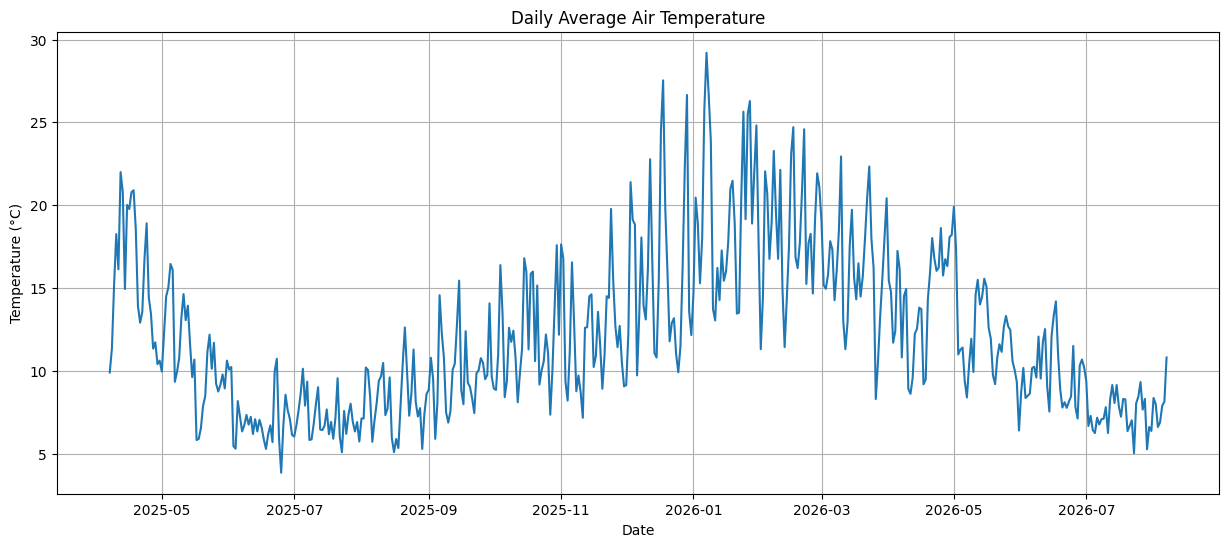

In [8]:
plt.figure(figsize=(15, 6))

plt.plot(
    daily_temp.index,
    daily_temp.values
)

plt.title(
    "Daily Average Air Temperature"
)

plt.xlabel("Date")
plt.ylabel("Temperature (°C)")

plt.grid(True)

plt.show()

# ADF stationarity test

In [9]:
print("=" * 60)
print("AUGMENTED DICKEY-FULLER (ADF) TEST")
print("=" * 60)

adf_result = adfuller(
    daily_temp,
    autolag="AIC"
)

print("ADF Statistic :", adf_result[0])
print("p-value       :", adf_result[1])
print("Lags Used     :", adf_result[2])
print("Observations  :", adf_result[3])

print("\nCritical Values:")

for key, value in adf_result[4].items():
    print(f"{key}: {value}")

# Decision
if adf_result[1] < 0.05:

    print("\nResult:")
    print("p-value < 0.05")
    print("The time series is STATIONARY.")

else:

    print("\nResult:")
    print("p-value >= 0.05")
    print("The time series is NON-STATIONARY.")

AUGMENTED DICKEY-FULLER (ADF) TEST
ADF Statistic : -1.4198322151728857
p-value       : 0.572732246153229
Lags Used     : 18
Observations  : 468

Critical Values:
1%: -3.4444002781824477
5%: -2.867735576537528
10%: -2.57007000456571

Result:
p-value >= 0.05
The time series is NON-STATIONARY.


The original series is non-stationary.
Applying first-order differencing...

ADF Test After Differencing
--------------------------------------------------
ADF Statistic: -8.176171530775067
p-value: 8.365718429278206e-13

The differenced series is STATIONARY.


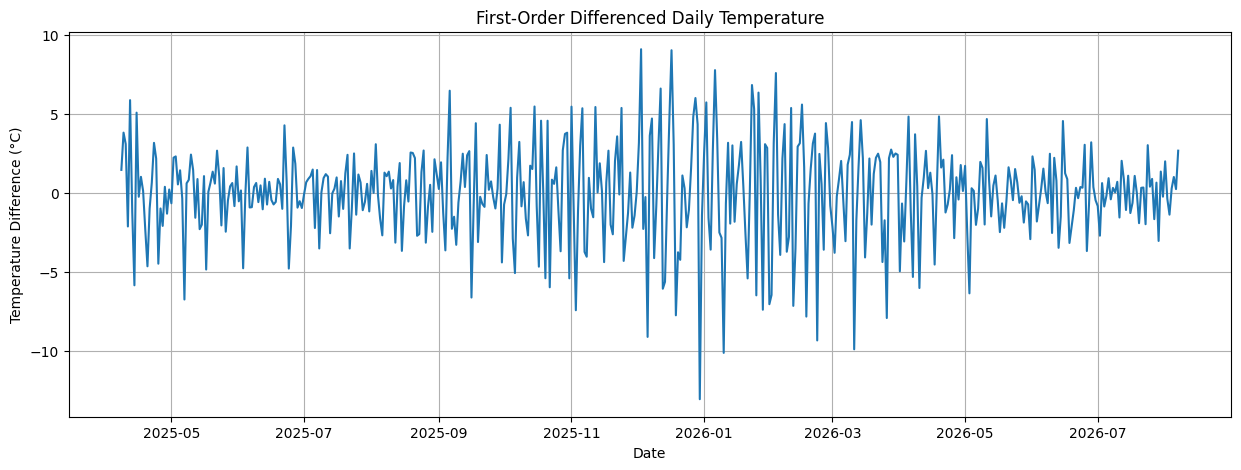

In [10]:
if adf_result[1] >= 0.05:

    print("The original series is non-stationary.")
    print("Applying first-order differencing...")

    daily_temp_diff = daily_temp.diff().dropna()

    # ADF test after differencing
    adf_diff_result = adfuller(
        daily_temp_diff,
        autolag="AIC"
    )

    print("\nADF Test After Differencing")
    print("-" * 50)

    print(
        "ADF Statistic:",
        adf_diff_result[0]
    )

    print(
        "p-value:",
        adf_diff_result[1]
    )

    if adf_diff_result[1] < 0.05:
        print("\nThe differenced series is STATIONARY.")
    else:
        print("\nThe differenced series is still NON-STATIONARY.")

    # Plot differenced data
    plt.figure(figsize=(15, 5))

    plt.plot(
        daily_temp_diff.index,
        daily_temp_diff.values
    )

    plt.title(
        "First-Order Differenced Daily Temperature"
    )

    plt.xlabel("Date")
    plt.ylabel("Temperature Difference (°C)")

    plt.grid(True)

    plt.show()

else:

    print("The original series is stationary.")
    print("Differencing is NOT required.")

    # Keep original series
    daily_temp_diff = daily_temp.copy()

# Time-series decomposition

TIME SERIES DECOMPOSITION


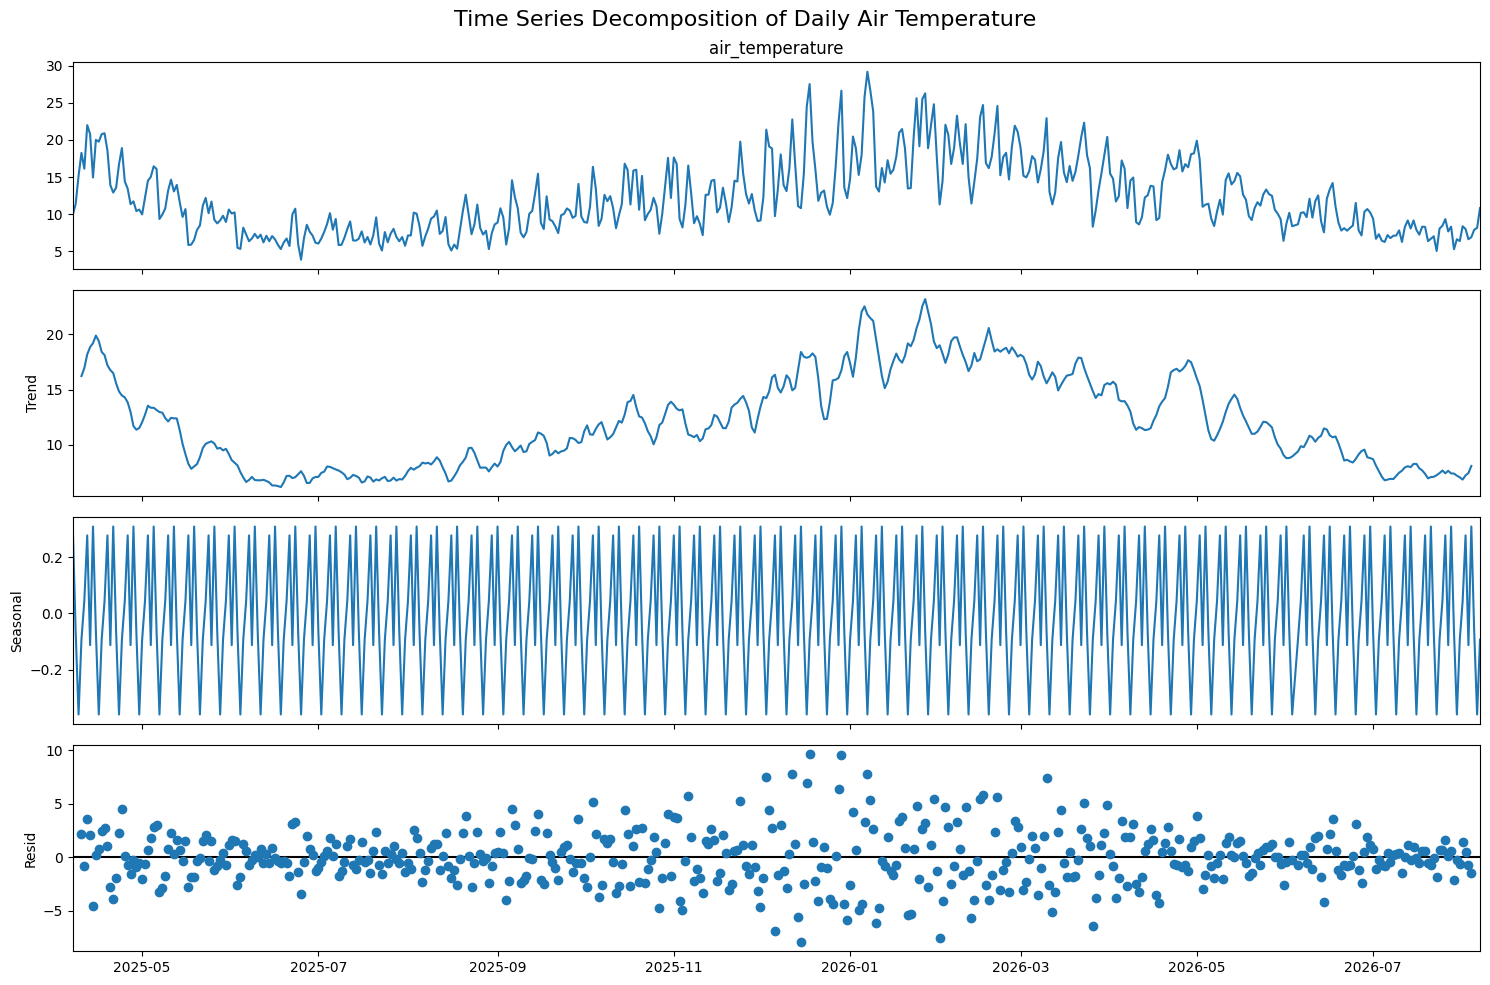

In [11]:
print("=" * 60)
print("TIME SERIES DECOMPOSITION")
print("=" * 60)

decomposition = seasonal_decompose(
    daily_temp,
    model="additive",
    period=7
)

fig = decomposition.plot()

fig.set_size_inches(15, 10)

plt.suptitle(
    "Time Series Decomposition of Daily Air Temperature",
    fontsize=16
)

plt.tight_layout()

plt.show()

# Plot decomposition components separately

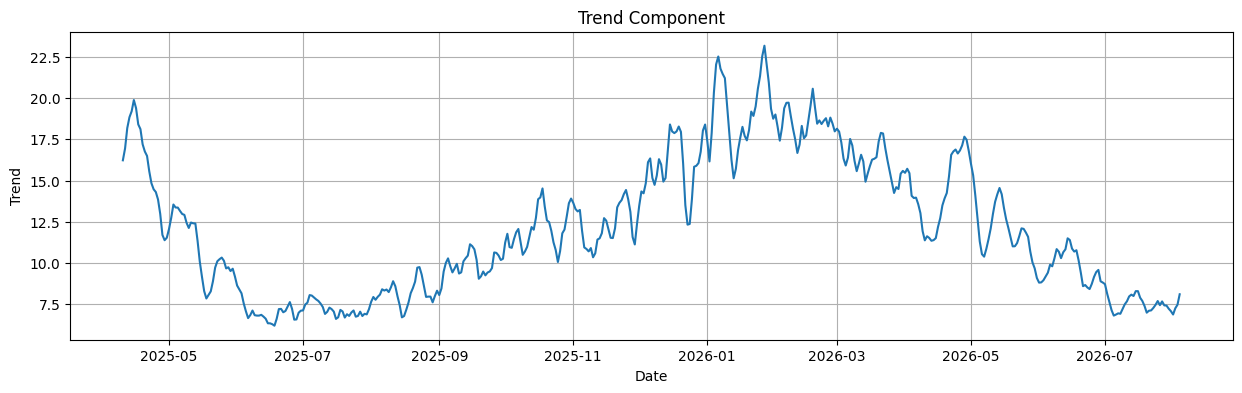

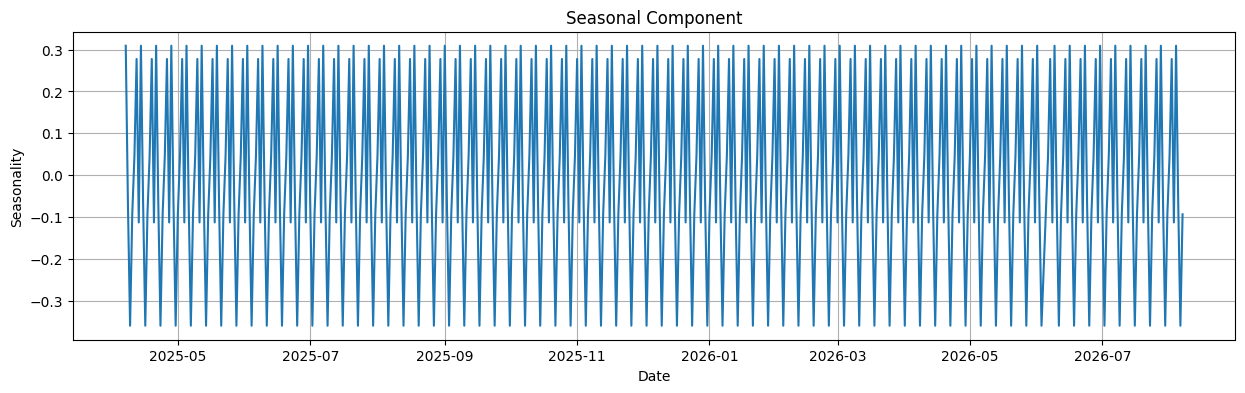

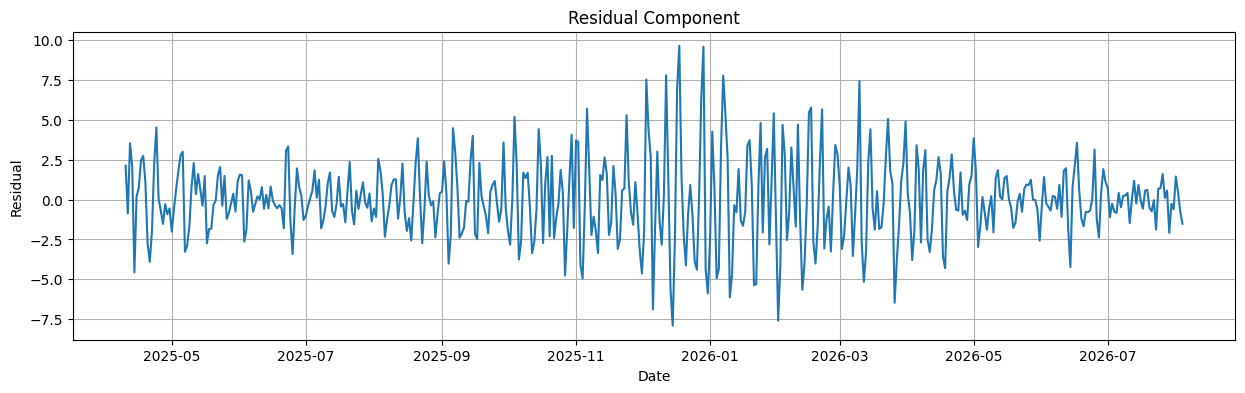

In [12]:
# Trend
plt.figure(figsize=(15, 4))

plt.plot(
    decomposition.trend
)

plt.title("Trend Component")

plt.xlabel("Date")
plt.ylabel("Trend")

plt.grid(True)

plt.show()


# Seasonal
plt.figure(figsize=(15, 4))

plt.plot(
    decomposition.seasonal
)

plt.title("Seasonal Component")

plt.xlabel("Date")
plt.ylabel("Seasonality")

plt.grid(True)

plt.show()


# Residual
plt.figure(figsize=(15, 4))

plt.plot(
    decomposition.resid
)

plt.title("Residual Component")

plt.xlabel("Date")
plt.ylabel("Residual")

plt.grid(True)

plt.show()

# Calculate Simple Moving Averages

In [13]:
# Calculate moving averages

daily_temp_df = pd.DataFrame(
    {"Temperature": daily_temp}
)

daily_temp_df["SMA_7"] = (
    daily_temp_df["Temperature"]
    .rolling(window=7)
    .mean()
)

daily_temp_df["SMA_30"] = (
    daily_temp_df["Temperature"]
    .rolling(window=30)
    .mean()
)

daily_temp_df["SMA_90"] = (
    daily_temp_df["Temperature"]
    .rolling(window=90)
    .mean()
)

display(
    daily_temp_df.tail(10)
)

,Temperature,SMA_7,SMA_30,SMA_90
date_time,,,,
2026-07-29 00:00:00+00:00,5.267241,7.443088,7.564652,9.950532
2026-07-30 00:00:00+00:00,6.615625,7.669130,7.444467,9.821799
2026-07-31 00:00:00+00:00,6.374000,7.429430,7.344076,9.671399
2026-08-01 00:00:00+00:00,8.368627,7.418400,7.400520,9.571576
2026-08-02 00:00:00+00:00,7.995522,7.227990,7.423958,9.538283
2026-08-03 00:00:00+00:00,6.616129,7.078279,7.430193,9.486422
2026-08-04 00:00:00+00:00,6.894203,6.875907,7.451774,9.436288
2026-08-05 00:00:00+00:00,7.900000,7.252015,7.475899,9.419838
2026-08-06 00:00:00+00:00,8.139706,7.469741,7.521615,9.416999


# Plot the moving averages

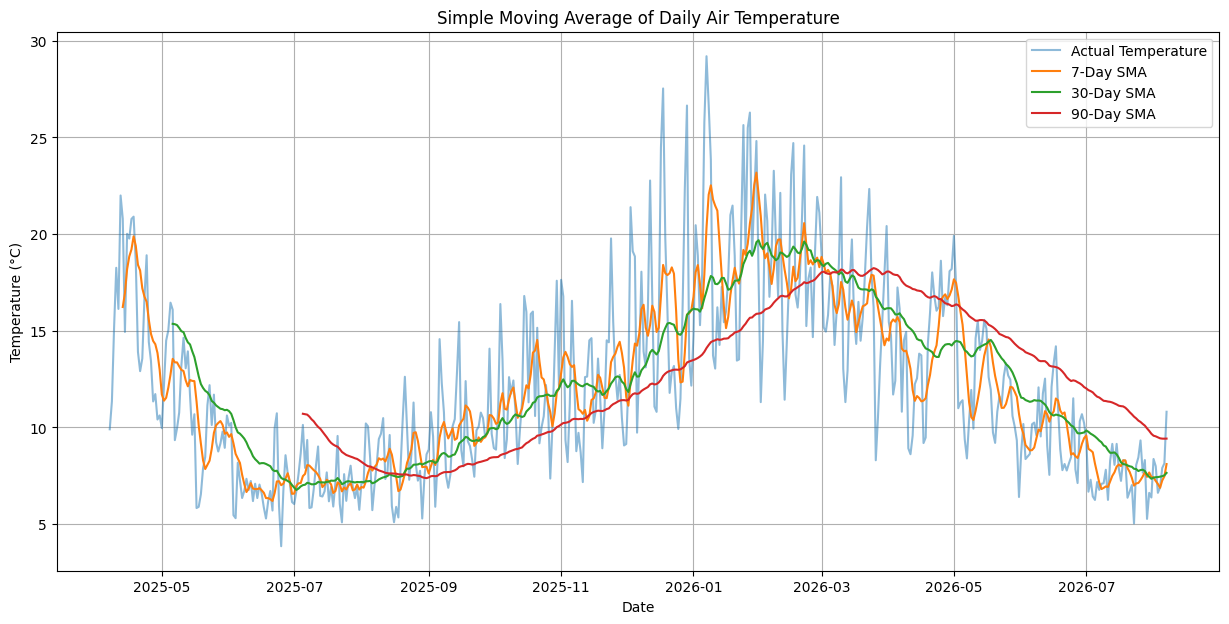

In [14]:
plt.figure(figsize=(15, 7))

plt.plot(
    daily_temp_df.index,
    daily_temp_df["Temperature"],
    label="Actual Temperature",
    alpha=0.5
)

plt.plot(
    daily_temp_df.index,
    daily_temp_df["SMA_7"],
    label="7-Day SMA"
)

plt.plot(
    daily_temp_df.index,
    daily_temp_df["SMA_30"],
    label="30-Day SMA"
)

plt.plot(
    daily_temp_df.index,
    daily_temp_df["SMA_90"],
    label="90-Day SMA"
)

plt.title(
    "Simple Moving Average of Daily Air Temperature"
)

plt.xlabel("Date")
plt.ylabel("Temperature (°C)")

plt.legend()

plt.grid(True)

plt.show()

# Create the 7-day train/test split

In [15]:
forecast_horizon = 7

# Training data
train = daily_temp.iloc[
    :-forecast_horizon
]

# Held-out test data
test = daily_temp.iloc[
    -forecast_horizon:
]

print("TRAINING DATA")
print("=" * 50)

print(
    "Start:",
    train.index.min()
)

print(
    "End:",
    train.index.max()
)

print(
    "Number of observations:",
    len(train)
)


print("\nTEST DATA")
print("=" * 50)

print(
    "Start:",
    test.index.min()
)

print(
    "End:",
    test.index.max()
)

print(
    "Number of observations:",
    len(test)
)


print("\nActual held-out values:")
display(test)

TRAINING DATA
Start: 2025-04-07 00:00:00+00:00
End: 2026-07-31 00:00:00+00:00
Number of observations: 480

TEST DATA
Start: 2026-08-01 00:00:00+00:00
End: 2026-08-07 00:00:00+00:00
Number of observations: 7

Actual held-out values:


,air_temperature
date_time,
2026-08-01 00:00:00+00:00,8.368627
2026-08-02 00:00:00+00:00,7.995522
2026-08-03 00:00:00+00:00,6.616129
2026-08-04 00:00:00+00:00,6.894203
2026-08-05 00:00:00+00:00,7.900000
2026-08-06 00:00:00+00:00,8.139706
2026-08-07 00:00:00+00:00,10.810000


# Forecast next 7 days using Moving Average

In [16]:
window = 7

# Store historical training observations
history = list(train.values)

ma_forecasts = []

# Forecast 7 future days
for i in range(forecast_horizon):

    # Average of most recent 7 observations
    forecast = np.mean(
        history[-window:]
    )

    ma_forecasts.append(
        forecast
    )

    # Add forecast to history
    # for recursive forecasting
    history.append(
        forecast
    )

# Convert to numpy array
ma_forecasts = np.array(
    ma_forecasts
)

print("7-Day Moving Average Forecast")
print("=" * 50)

for date, forecast in zip(
    test.index,
    ma_forecasts
):

    print(
        date.strftime("%Y-%m-%d"),
        "->",
        round(forecast, 2),
        "°C"
    )

7-Day Moving Average Forecast
2026-08-01 -> 7.43 °C
2026-08-02 -> 7.28 °C
2026-08-03 -> 6.99 °C
2026-08-04 -> 6.9 °C
2026-08-05 -> 6.69 °C
2026-08-06 -> 6.9 °C
2026-08-07 -> 6.94 °C


# Forecast next 7 days using Naive method

In [17]:
# Last value in training data
last_value = train.iloc[-1]

# Repeat it for the next 7 days
naive_forecasts = np.repeat(
    last_value,
    forecast_horizon
)

print("Naive Forecast")
print("=" * 50)

print(
    "Last observed training temperature:",
    round(last_value, 2),
    "°C"
)

print()

for date, forecast in zip(
    test.index,
    naive_forecasts
):

    print(
        date.strftime("%Y-%m-%d"),
        "->",
        round(forecast, 2),
        "°C"
    )

Naive Forecast
Last observed training temperature: 6.37 °C

2026-08-01 -> 6.37 °C
2026-08-02 -> 6.37 °C
2026-08-03 -> 6.37 °C
2026-08-04 -> 6.37 °C
2026-08-05 -> 6.37 °C
2026-08-06 -> 6.37 °C
2026-08-07 -> 6.37 °C


# Compare actual vs forecasts

In [19]:
forecast_results = pd.DataFrame({

    "Actual": test.values,

    "Moving_Average_7_Day":
        ma_forecasts,

    "Naive":
        naive_forecasts

}, index=test.index)

print("FORECAST RESULTS")
print("=" * 70)

display(
    forecast_results.round(2)
)

FORECAST RESULTS


,Actual,Moving_Average_7_Day,Naive
date_time,,,
2026-08-01 00:00:00+00:00,8.37,7.43,6.37
2026-08-02 00:00:00+00:00,8.00,7.28,6.37
2026-08-03 00:00:00+00:00,6.62,6.99,6.37
2026-08-04 00:00:00+00:00,6.89,6.90,6.37
2026-08-05 00:00:00+00:00,7.90,6.69,6.37
2026-08-06 00:00:00+00:00,8.14,6.90,6.37
2026-08-07 00:00:00+00:00,10.81,6.94,6.37


# Calculate MAE

In [20]:
# MAE for Moving Average
mae_moving_average = mean_absolute_error(
    test,
    ma_forecasts
)

# MAE for Naive
mae_naive = mean_absolute_error(
    test,
    naive_forecasts
)

print("=" * 60)
print("FORECAST ERROR - MEAN ABSOLUTE ERROR (MAE)")
print("=" * 60)

print(
    "7-Day Moving Average MAE:",
    round(mae_moving_average, 4),
    "°C"
)

print(
    "Naive MAE:",
    round(mae_naive, 4),
    "°C"
)

FORECAST ERROR - MEAN ABSOLUTE ERROR (MAE)
7-Day Moving Average MAE: 1.1926 °C
Naive MAE: 1.7295 °C


# Determine the better forecasting method

In [21]:
if mae_moving_average < mae_naive:

    best_method = "7-Day Moving Average"

else:

    best_method = "Naive Method"


print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

print(
    "Moving Average MAE:",
    round(mae_moving_average, 4)
)

print(
    "Naive MAE:",
    round(mae_naive, 4)
)

print(
    "\nBest method:",
    best_method
)

MODEL COMPARISON
Moving Average MAE: 1.1926
Naive MAE: 1.7295

Best method: 7-Day Moving Average


# Plot actual vs forecasts

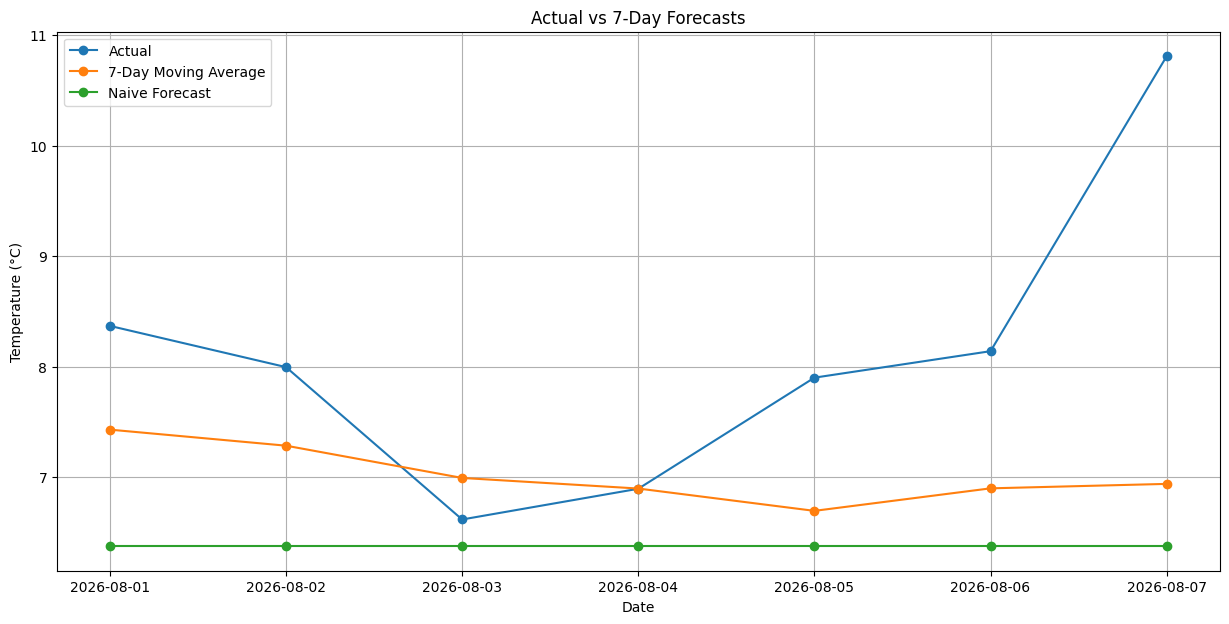

In [22]:
plt.figure(figsize=(15, 7))

plt.plot(
    test.index,
    test.values,
    marker="o",
    label="Actual"
)

plt.plot(
    test.index,
    ma_forecasts,
    marker="o",
    label="7-Day Moving Average"
)

plt.plot(
    test.index,
    naive_forecasts,
    marker="o",
    label="Naive Forecast"
)

plt.title(
    "Actual vs 7-Day Forecasts"
)

plt.xlabel("Date")

plt.ylabel(
    "Temperature (°C)"
)

plt.legend()

plt.grid(True)

plt.show()

# 7-Day Moving Average and Naive

In [23]:
summary = pd.DataFrame({

    "Forecast Method": [
        "7-Day Moving Average",
        "Naive"
    ],

    "MAE (°C)": [
        mae_moving_average,
        mae_naive
    ]

})

summary["MAE (°C)"] = summary["MAE (°C)"].round(4)

display(summary)

,Forecast Method,MAE (°C)
0,7-Day Moving Average,1.1926
1,Naive,1.7295
